In [1]:
from sklearn.feature_selection import mutual_info_regression
import matplotlib.patheffects as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import sys
from networkx.algorithms import bipartite
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
csv_path = "df_all_tx_micro.csv"   
df_all = pd.read_csv(csv_path)

print("df_all:", df_all.shape)

/var/folders/tr/wk54pth147n6y95tl01czm000000gn/T/ipykernel_40406/3525381595.py:2: DtypeWarning: Columns (67,68,224,225,226,228,287,384,424,425,426,427,428,429,470) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(csv_path)


df_all: (77, 61250)


In [3]:
df_all = pd.read_csv(csv_path, low_memory=False)
print("df_all:", df_all.shape)

df_all: (77, 61250)


In [4]:
micro_cols = [c for c in df_all.columns if str(c).startswith("micro__")]
tx_cols    = [c for c in df_all.columns if str(c).startswith("tx__")]

print("micro cols:", len(micro_cols))
print("tx cols:", len(tx_cols))

micro cols: 4994
tx cols: 55765


In [5]:
# separar features
X_micro = df_all.filter(regex=r"^micro__").copy()
X_tx    = df_all.filter(regex=r"^tx__").copy()

print("X_micro:", X_micro.shape)
print("X_tx   :", X_tx.shape)



def prep_X(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.dropna(axis=0, how="any")         
    X = X.loc[:, X.nunique(dropna=True) > 1] # quitar constantes
    return X

X_micro = prep_X(X_micro)
X_tx    = prep_X(X_tx)

# alinear por índice (por si se cayeron filas)
idx = X_micro.index.intersection(X_tx.index)
X_micro = X_micro.loc[idx]
X_tx    = X_tx.loc[idx]

print("After prep - X_micro:", X_micro.shape, "X_tx:", X_tx.shape)

X_micro: (77, 4994)
X_tx   : (77, 55765)
After prep - X_micro: (77, 4090) X_tx: (77, 49959)


In [6]:
#entonces aqui lo que tenemos que hacer es buscar los datos de dieta usando el user id para ese mismo numero de visita y numero de semana en otros estudios, pero como no los tenemos seguimos con la red
#decidí todavía no hacerlo porque quiero avanzar sobre lo demás
def top_by_variance(X, top_n):
    v = X.var(axis=0).sort_values(ascending=False)
    return X.loc[:, v.index[:top_n]]

#reducir por los más altos, para que sea chiquita 

X_tx_small    = top_by_variance(X_tx, 500)
X_micro_small = top_by_variance(X_micro, 50)

In [7]:
print("X_micro:", X_micro.shape)
print("X_micro_small:", X_micro_small.shape)


print("First 5 cols X_micro_small:")
print(list(X_micro_small.columns[:5]))

X_micro: (77, 4090)
X_micro_small: (77, 50)
First 5 cols X_micro_small:
['micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.84', 'micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.162', 'micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.110', 'micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.123', 'micro__Bacteria; __Bacteroidetes; __Bacteroidia; __Bacteroidales; __Bacteroidaceae; __Bacteroides.136']


In [8]:
#vamos a ver como estamos de culumnas duplicadas, no era alli el problema, pero igual fue un buen check así que se queda
#problema resuelto, era una cosa de nombres de variables 

print("X_micro shape:", X_micro.shape)

dup_mask = X_micro.columns.duplicated(keep=False)
print("# of duplicated columns:", int(dup_mask.sum()))
print("# of unique names:", X_micro.columns.nunique())


X_micro shape: (77, 4090)
# of duplicated columns: 0
# of unique names: 4090


In [9]:
#alinear filas
idx = X_micro_small.index.intersection(X_tx_small.index)

A = X_micro_small.loc[idx].copy()
B = X_tx_small.loc[idx].copy()

In [10]:
print("X_micro_small:", X_micro_small.shape)
print("A:", A.shape)
print("A cols:", len(A.columns))

X_micro_small: (77, 50)
A: (77, 50)
A cols: 50


In [11]:
print(df_all["diagnosis"].value_counts(dropna=False))

diagnosis
CD        34
UC        22
nonIBD    21
Name: count, dtype: int64


In [12]:
def collapse_duplicate_columns_mean(X):
    return X.T.groupby(level=0).mean().T

def get_X_by_group(df_sub):
    micro_cols = [c for c in df_sub.columns if c.startswith("micro__")]
    tx_cols    = [c for c in df_sub.columns if c.startswith("tx__")]

    X_micro = df_sub[micro_cols].copy()
    X_tx    = df_sub[tx_cols].copy()



    return X_micro, X_tx

df_cd     = df_all[df_all["diagnosis"] == "CD"].copy()
df_uc     = df_all[df_all["diagnosis"] == "UC"].copy()
df_nonibd = df_all[df_all["diagnosis"] == "nonIBD"].copy()

for name, df_sub in [("CD", df_cd), ("UC", df_uc), ("nonIBD", df_nonibd)]:
    X_micro, X_tx = get_X_by_group(df_sub)
    print("\n==", name, "==")
    print("n samples:", df_sub.shape[0])
    print("X_micro (after collapse):", X_micro.shape, "| duplicated cols:", int(X_micro.columns.duplicated().sum()))
    print("X_tx:", X_tx.shape)


== CD ==
n samples: 34
X_micro (after collapse): (34, 4994) | duplicated cols: 0
X_tx: (34, 55765)

== UC ==
n samples: 22
X_micro (after collapse): (22, 4994) | duplicated cols: 0
X_tx: (22, 55765)

== nonIBD ==
n samples: 21
X_micro (after collapse): (21, 4994) | duplicated cols: 0
X_tx: (21, 55765)


In [13]:
def top_by_variance(X, top_n):
    v = X.var(axis=0).sort_values(ascending=False)
    return X.loc[:, v.index[:top_n]]

TOP_TX = 500
TOP_MICRO = 50

for name, df_sub in [("CD", df_cd), ("UC", df_uc), ("nonIBD", df_nonibd)]:
    X_micro_u, X_tx = get_X_by_group(df_sub)

    X_micro_small = top_by_variance(X_micro_u, TOP_MICRO)
    X_tx_small    = top_by_variance(X_tx, TOP_TX)

    #quitar constantes raras 
    X_micro_small = X_micro_small.loc[:, X_micro_small.nunique(dropna=True) > 1]
    X_tx_small    = X_tx_small.loc[:, X_tx_small.nunique(dropna=True) > 1]

    print("\n==", name, "==")
    print("X_micro_small:", X_micro_small.shape)
    print("X_tx_small:", X_tx_small.shape)


== CD ==
X_micro_small: (34, 50)
X_tx_small: (34, 500)

== UC ==
X_micro_small: (22, 50)
X_tx_small: (22, 500)

== nonIBD ==
X_micro_small: (21, 50)
X_tx_small: (21, 500)


In [14]:
#puse 3 de bandwith para no tener bins vacios, 
#si quiero aumentar este bins tengo que agregar un cacho de código que tire las columnas con bins vacios 

def discretize_equal_width(X, n_bins=3, verbose=True):
    X = X.copy()

    # 1) detectar columnas constantes (solo reportar, NO quitar)
    nun = X.nunique(dropna=True)
    const_cols = nun[nun <= 1].index.tolist()

    # 2) NaNs: imputar con mediana
    if X.isna().any().any():
        X = X.apply(lambda s: s.fillna(s.median()), axis=0)

    # 3) discretizar (equal bandwidth = uniform)
    est = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="uniform")

    try:
        Z = est.fit_transform(X.values)
    except Exception as e:
        print("ERROR @ KBinsDiscretizer:", repr(e))
        print("n_bins:", n_bins)
        print("Cols input:", X.shape[1])
        print("Cols constant:", len(const_cols))
        if len(const_cols) > 0:
            print("Example of constant columns:", const_cols[:10])
        raise

    Xb = pd.DataFrame(Z, index=X.index, columns=X.columns).astype(int)

    if verbose:
        print("n_bins:", n_bins)
        print("Cols input:", X.shape[1])
        print("Cols constant found:", len(const_cols))
        if len(const_cols) > 0:
            print("Example of const cols:", const_cols[:10])
        print("Cols output:", Xb.shape[1])

    return Xb, est, const_cols

#revisar si hay bins vacios y todo va a valer 



In [15]:
def report_empty_bins(Xb, n_bins, top=15):
    # Xb: dataframe discretizado (enteros)
    used = Xb.nunique(dropna=True)                  # bins usados por columna
    missing = n_bins - used                         # bins faltantes por columna
    out = pd.DataFrame({"bins_used": used, "bins_missing": missing})
    out = out.sort_values(["bins_missing", "bins_used"], ascending=[False, True])

    n_cols_with_empty = int((out["bins_missing"] > 0).sum())
    print("Total cols:", Xb.shape[1])
    print("Cols with >=1 empty bin :", n_cols_with_empty)
    print("bins_used:")
    print(out["bins_used"].value_counts().sort_index())
    print("\nTop columns with more empty bins:")
    print(out.head(top))

    return out
# 1) sacar X_micro del grupo
X_micro_u_cd, X_tx_cd = get_X_by_group(df_cd)

# 2) reducir (como acordamos)
X_micro_small_cd = top_by_variance(X_micro_u_cd, 30)

# 3) discretizar (elige bins=3 por ejemplo)
X_micro_bin, est_micro, const_micro = discretize_equal_width(X_micro_small_cd, n_bins=3, verbose=True)

# 4) bins vacíos
out_micro = report_empty_bins(X_micro_bin, n_bins=3, top=15)

n_bins: 3
Cols input: 30
Cols constant found: 0
Cols output: 30
Total cols: 30
Cols with >=1 empty bin : 0
bins_used:
bins_used
3    30
Name: count, dtype: int64

Top columns with more empty bins:
                                                    bins_used  bins_missing
micro__Bacteria; __Bacteroidetes; __Bacteroidia...          3             0
micro__Bacteria; __Bacteroidetes; __Bacteroidia...          3             0
micro__Bacteria; __Bacteroidetes; __Bacteroidia...          3             0
micro__Bacteria; __Bacteroidetes; __Bacteroidia...          3             0
micro__Bacteria; __Bacteroidetes; __Bacteroidia...          3             0
micro__Bacteria; __Bacteroidetes; __Bacteroidia...          3             0
micro__Bacteria; __Bacteroidetes; __Bacteroidia...          3             0
micro__Bacteria; __Bacteroidetes; __Bacteroidia...          3             0
micro__Bacteria; __Bacteroidetes; __Bacteroidia...          3             0
micro__Bacteria; __Bacteroidetes; __Bactero

In [23]:

def build_MI_continuous(df_sub, name, top_micro=50, top_tx=500, seed=42):
    # 1) matrices base (ya colapsa duplicados en micro adentro)
    X_micro_u, X_tx = get_X_by_group(df_sub)

    # 2) top variance DENTRO del grupo
    X_micro_small = top_by_variance(X_micro_u, top_micro)
    X_tx_small    = top_by_variance(X_tx, top_tx)

    # 3) alinear filas
    idx = X_micro_small.index.intersection(X_tx_small.index)
    A = X_micro_small.loc[idx].copy()
    B = X_tx_small.loc[idx].copy()

    # 4) quitar constantes
    A = A.loc[:, A.nunique(dropna=True) > 1]
    B = B.loc[:, B.nunique(dropna=True) > 1]

    print(f"\n== {name} ==")
    print("n samples:", df_sub.shape[0])
    print("A (micro):", A.shape, "| B (tx):", B.shape)

    # 5) MI (micro vs cada gen)
    MI = pd.DataFrame(index=A.columns, columns=B.columns, dtype=float)
    A_vals = A.values

    for gene in B.columns:
        y = B[gene].values
        MI[gene] = mutual_info_regression(A_vals, y, random_state=seed)

    print("MI shape:", MI.shape)
    print(MI.stack().describe())

    return MI

MI_CD     = build_MI_continuous(df_cd, "CD", top_micro=50, top_tx=500, seed=42)
MI_UC     = build_MI_continuous(df_uc, "UC", top_micro=50, top_tx=500, seed=42)
MI_nonIBD = build_MI_continuous(df_nonibd, "nonIBD", top_micro=50, top_tx=500, seed=42)


== CD ==
n samples: 34
A (micro): (34, 50) | B (tx): (34, 500)
MI shape: (50, 500)
count    25000.000000
mean         0.032353
std          0.049296
min          0.000000
25%          0.000000
50%          0.001246
75%          0.052136
max          0.322288
dtype: float64

== UC ==
n samples: 22
A (micro): (22, 50) | B (tx): (22, 500)
MI shape: (50, 500)
count    25000.000000
mean         0.016133
std          0.032365
min          0.000000
25%          0.000000
50%          0.000000
75%          0.018241
max          0.440639
dtype: float64

== nonIBD ==
n samples: 21
A (micro): (21, 50) | B (tx): (21, 500)
MI shape: (50, 500)
count    25000.000000
mean         0.032924
std          0.056956
min          0.000000
25%          0.000000
50%          0.000000
75%          0.047465
max          0.459148
dtype: float64


In [24]:
def edges_from_MI(MI, pctl=99.5):
    thr = np.nanpercentile(MI.values.flatten(), pctl)
    edges = (MI.stack()
               .reset_index()
               .rename(columns={"level_0":"micro_node","level_1":"tx_node",0:"MI"}))
    edges = edges[edges["MI"] >= thr].sort_values("MI", ascending=False).reset_index(drop=True)
    return edges, float(thr)

edges_CD, thr_CD = edges_from_MI(MI_CD, pctl=99.5)
edges_UC, thr_UC = edges_from_MI(MI_UC, pctl=99.5)
edges_non, thr_non = edges_from_MI(MI_nonIBD, pctl=99.5)

print("CD:     thr", thr_CD, "edges", edges_CD.shape[0])
print("UC:     thr", thr_UC, "edges", edges_UC.shape[0])
print("nonIBD: thr", thr_non, "edges", edges_non.shape[0])

# ver top 10 de cada uno
print("\nTop CD:")
print(edges_CD.head(10))
print("\nTop UC:")
print(edges_UC.head(10))
print("\nTop nonIBD:")
print(edges_non.head(10))

CD:     thr 0.25234081324714097 edges 126
UC:     thr 0.17520191191208667 edges 126
nonIBD: thr 0.28428803431567684 edges 136

Top CD:
                                          micro_node      tx_node        MI
0  micro__Bacteria; __Firmicutes; __Clostridia; _...  tx__CEACAM5  0.322288
1  micro__Bacteria; __Firmicutes; __Clostridia; _...  tx__CEACAM5  0.306052
2  micro__Bacteria; __Bacteroidetes; __Bacteroidi...     tx__MLEC  0.287169
3  micro__Bacteria; __Bacteroidetes; __Bacteroidi...     tx__MLEC  0.287169
4  micro__Bacteria; __Bacteroidetes; __Bacteroidi...     tx__MLEC  0.287169
5  micro__Bacteria; __Bacteroidetes; __Bacteroidi...     tx__MLEC  0.287169
6  micro__Bacteria; __Bacteroidetes; __Bacteroidi...     tx__MLEC  0.287169
7  micro__Bacteria; __Bacteroidetes; __Bacteroidi...     tx__MLEC  0.287169
8  micro__Bacteria; __Bacteroidetes; __Bacteroidi...     tx__MLEC  0.287169
9  micro__Bacteria; __Bacteroidetes; __Bacteroidi...     tx__MLEC  0.287169

Top UC:
                    

In [25]:
def build_bipartite_from_links(links_df):
    G = nx.Graph()
    for r in links_df.itertuples(index=False):
        G.add_node(r.micro_node, node_type="micro")
        G.add_node(r.tx_node, node_type="tx")
        G.add_edge(r.micro_node, r.tx_node, weight=float(r.MI))
    return G

G_CD  = build_bipartite_from_links(edges_CD)
G_UC  = build_bipartite_from_links(edges_UC)
G_non = build_bipartite_from_links(edges_non)

In [26]:
def micro_short(name):
    parts = [p.strip() for p in str(name).split(";") if p.strip()]
    last = parts[-1] if parts else str(name)
    return last.replace("__", "").replace("micro__", "").strip()

def plot_hairball_color(G, title, k=0.8, seed=42, label_micro=True, label_tx=True):
    plt.figure(figsize=(18, 12))
    pos = nx.spring_layout(G, seed=seed, k=k)  # mismo layout

    micro_nodes = [n for n,d in G.nodes(data=True) if d.get("node_type")=="micro"]
    tx_nodes    = [n for n,d in G.nodes(data=True) if d.get("node_type")=="tx"]

    # edges
    nx.draw_networkx_edges(G, pos, alpha=0.35)

    # nodes con colores
    nx.draw_networkx_nodes(G, pos, nodelist=micro_nodes, node_size=450, node_color="dodgerblue")
    nx.draw_networkx_nodes(G, pos, nodelist=tx_nodes,    node_size=250, node_color="seagreen")

    # labels
    labels = {}
    if label_micro:
        for n in micro_nodes:
            labels[n] = micro_short(n)
    if label_tx:
        for n in tx_nodes:
            labels[n] = n.replace("tx__", "")

    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

    plt.title(title)
    plt.axis("off")
    plt.show()

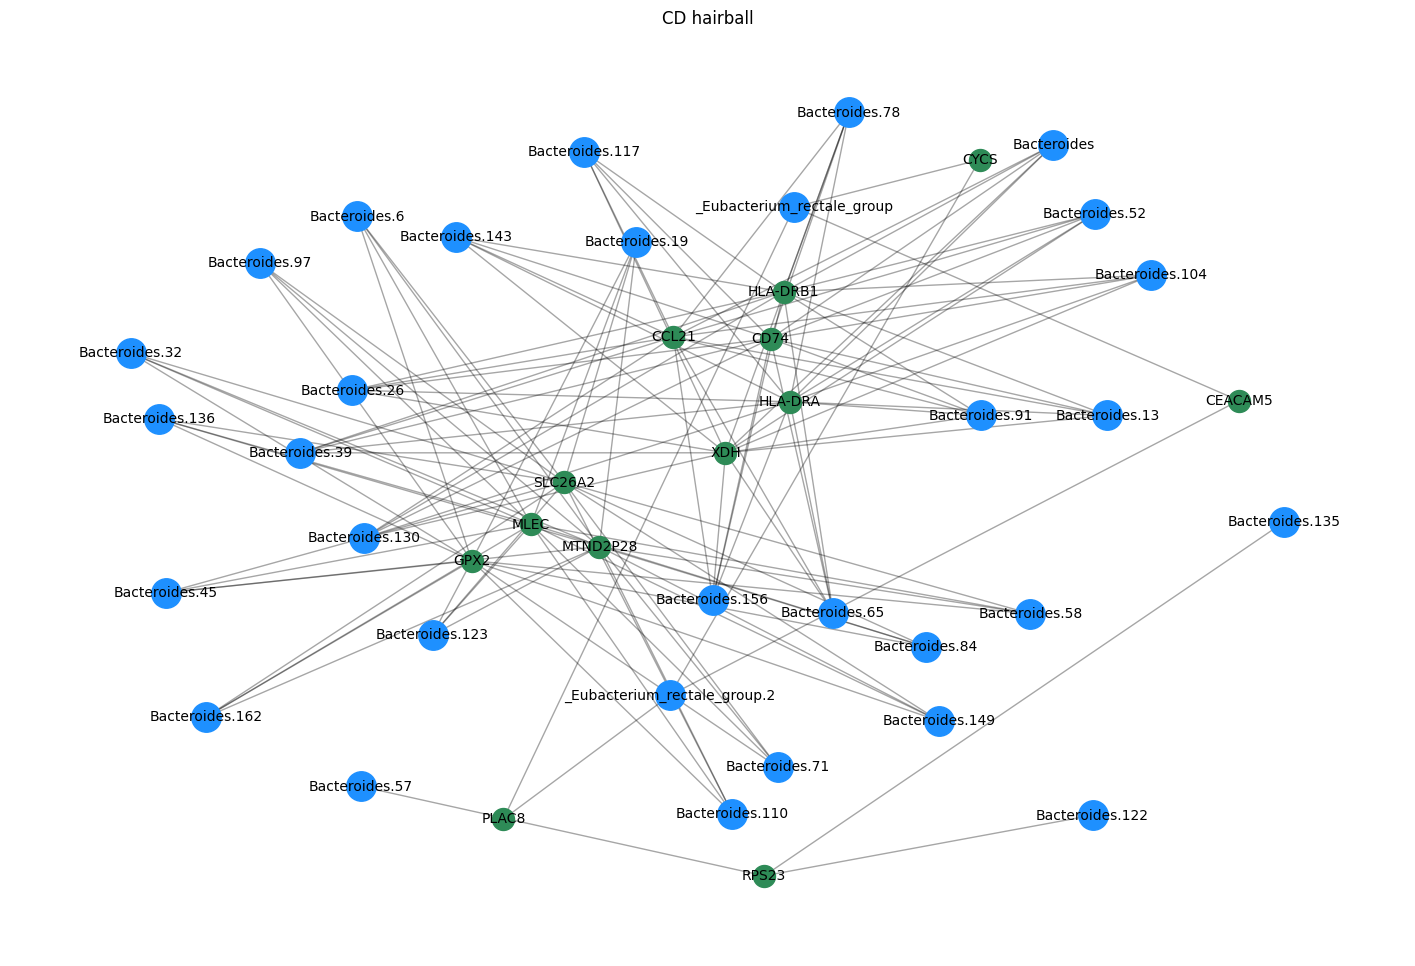

In [27]:
plot_hairball_color(G_CD,  "CD hairball", k=0.8, seed=42, label_micro=True)


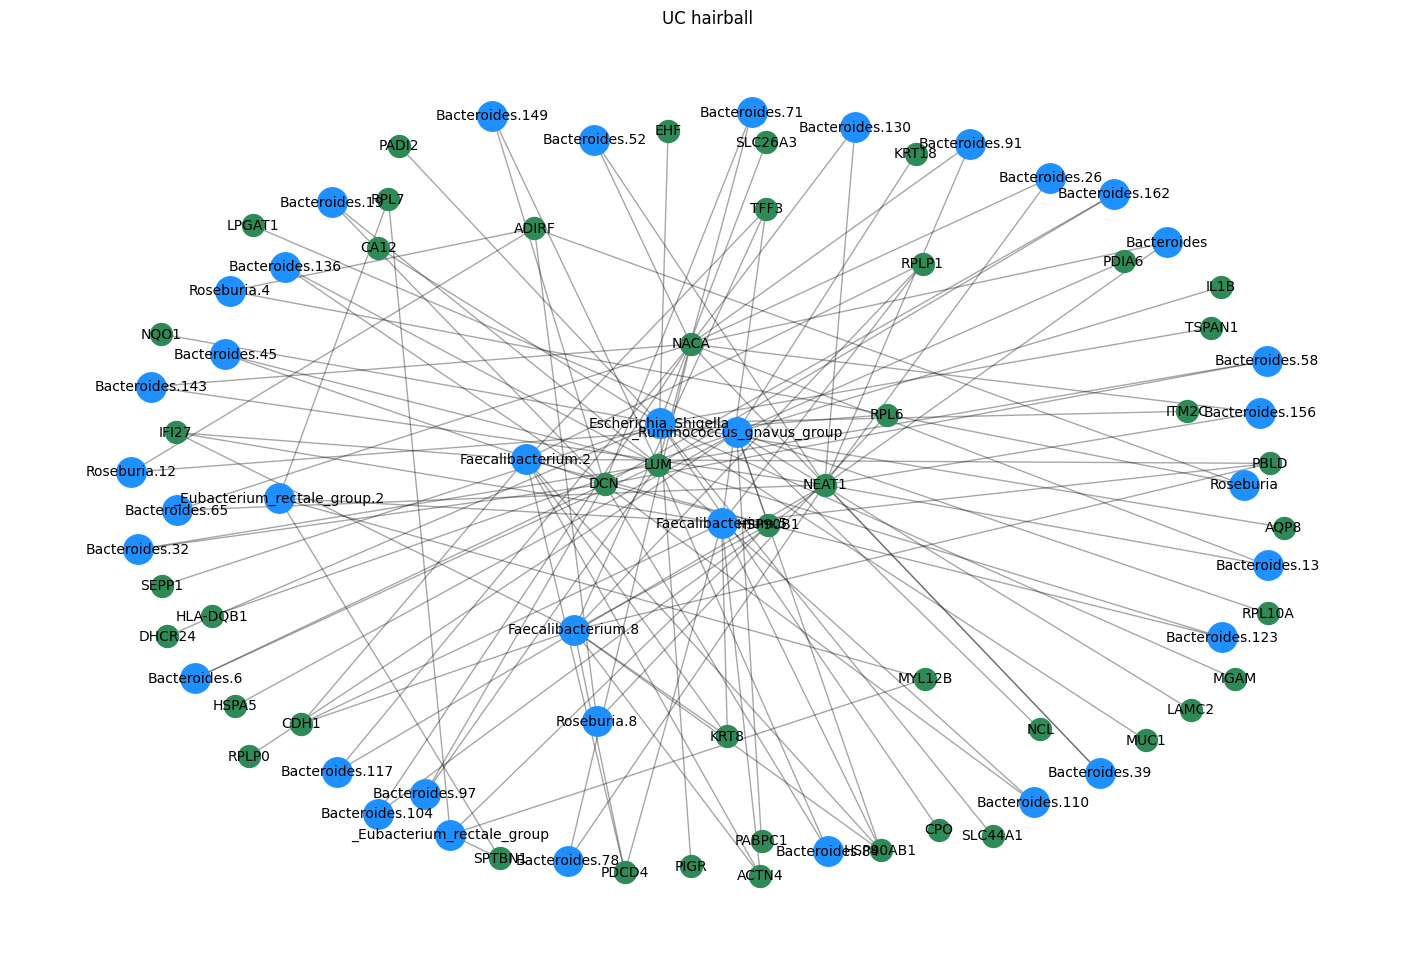

In [28]:
plot_hairball_color(G_UC,  "UC hairball", k=0.8, seed=42, label_micro=True, label_tx=True)

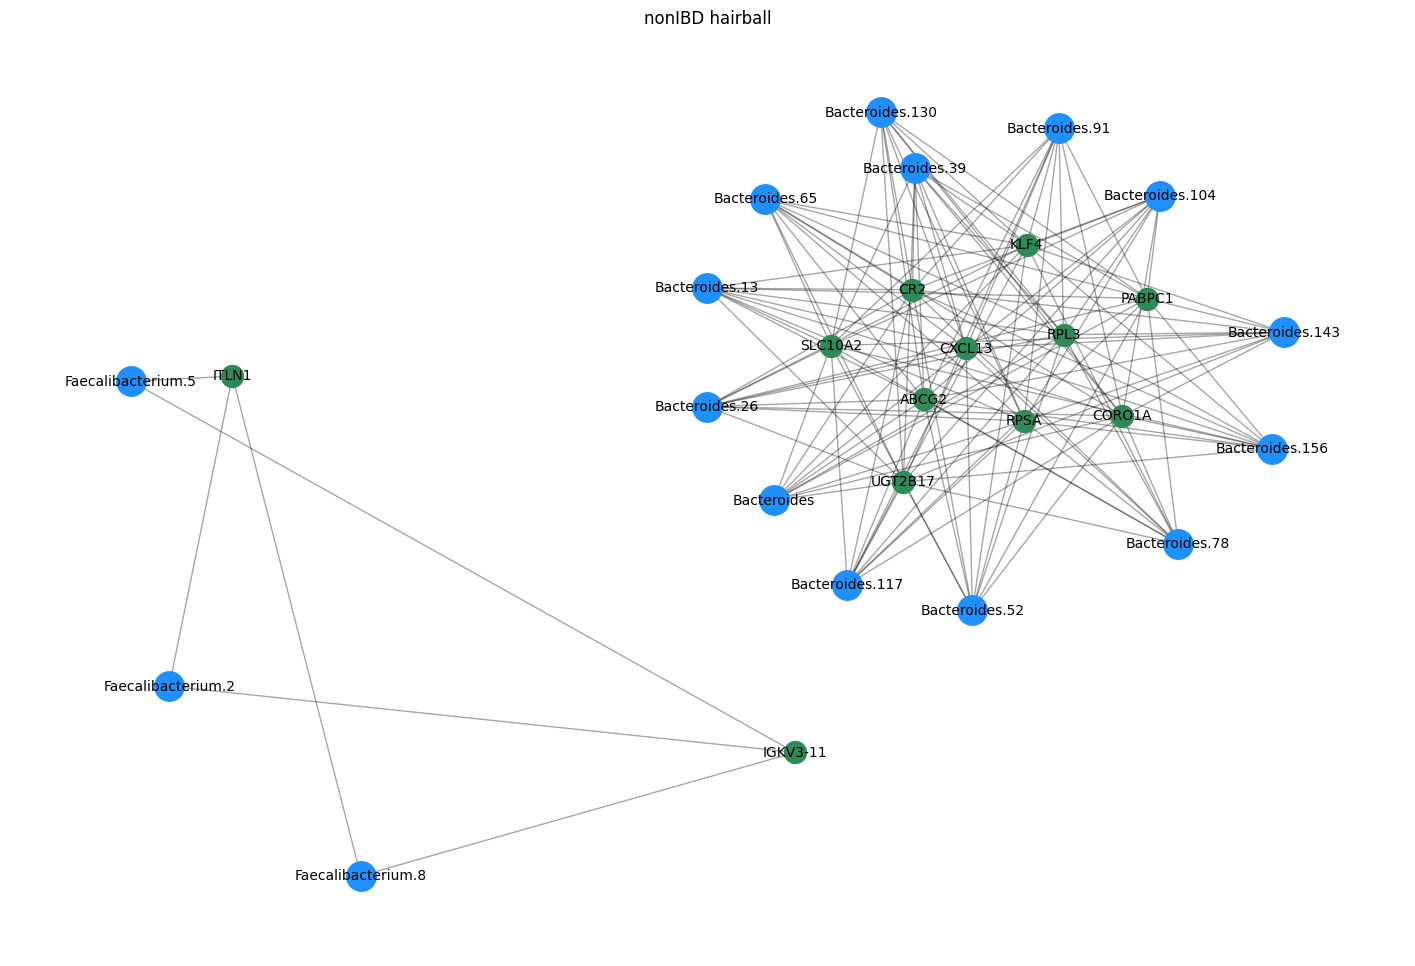

In [29]:
plot_hairball_color(G_non, "nonIBD hairball", k=0.8, seed=42, label_micro=True, label_tx=True)